# Who's hiring, and what they pay: 3,351 jobs from 15 hiring systems

This notebook explores the [Company Career Site Jobs with Salaries](https://www.kaggle.com/datasets/dhughes6071/company-career-site-jobs-with-salaries-oct-2026)
sample: open jobs collected straight from employers' own career sites (Workday, Oracle, Greenhouse, Lever
and 11 more hiring systems) between 1 and 7 Oct 2026.

It answers four quick questions:

1. Which hiring systems and countries do the jobs come from?
2. How often does a posting actually state the pay?
3. What do US jobs pay, by type of job?
4. How do hourly and salaried roles compare?

In [1]:
import glob
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# On Kaggle the file sits under /kaggle/input; elsewhere, next to the notebook.
path = (glob.glob("/kaggle/input/**/career-jobs-sample-*.csv", recursive=True)
        or glob.glob("career-jobs-sample-*.csv"))[0]
jobs = pd.read_csv(path, parse_dates=["postedAt", "firstSeenAt"])
plt.rcParams.update({"figure.figsize": (9, 4.5), "axes.spines.top": False, "axes.spines.right": False})
jobs.head()

,title,company,location,country,remote,department,employmentType,postedAt,firstSeenAt,salaryMin,salaryMax,salaryCurrency,salaryPeriod,salaryAnnualMin,salaryAnnualMax,hiringSystem,url
0,"Commercial Lines Account Assistant, SME",HUB International,"Oakville, ON",CA,False,Client Services,Full time,2026-10-05,2026-10-06,42000.0,51000.0,CAD,year,42000.0,51000.0,workday,https://hubinternational.wd1.myworkdayjobs.com...
1,Senior Visual Design Specialist,Taskrabbit,"New York, New York, United States; San Francis...",NaN,False,Marketing,NaN,2026-10-01,2026-10-07,89000.0,115000.0,USD,year,89000.0,115000.0,greenhouse,https://job-boards.greenhouse.io/taskrabbit/jo...
2,Façade Engineering-Structural- 0 to 5 Years Ex...,KPFF Consulting Engineers,"Portland, OR, United States",US,False,Portland Structural,Full-time,2026-10-05,2026-10-06,NaN,NaN,NaN,NaN,NaN,NaN,smartrecruiters,https://jobs.smartrecruiters.com/KPFFConsultin...
3,Insulation Installer,EIC,"Hurricane, UT, USA",US,False,Installer,Full time,2026-10-01,2026-10-02,15.0,20.0,USD,hour,31200.0,41600.0,ukg,https://recruiting.ultipro.com/IBP1000IBP/JobB...
4,Patient Care Technician - Stem Cell Transplant...,University of Arkansas System,Little Rock,US,True,Nursing (Non-Classified),Full time,2026-10-02,2026-10-03,NaN,NaN,NaN,NaN,NaN,NaN,workday,https://uasys.wd5.myworkdayjobs.com/UAMS_All_C...


In [2]:
has_pay = jobs["salaryMax"].notna()
print(f"{len(jobs):,} jobs from {jobs['company'].nunique():,} employers in {jobs['country'].nunique()} countries")
print(f"{jobs['hiringSystem'].nunique()} hiring systems; {has_pay.sum():,} jobs ({has_pay.mean():.0%}) state pay; "
      f"{jobs['remote'].mean():.0%} are remote")

3,351 jobs from 1,968 employers in 91 countries
15 hiring systems; 971 jobs (29%) state pay; 8% are remote


## 1. Where the jobs come from

Large employers mostly hire through Workday and Oracle; startups and smaller companies through Greenhouse,
Lever, Ashby, Workable and the rest. The sample keeps every system represented (at least 60 jobs each).

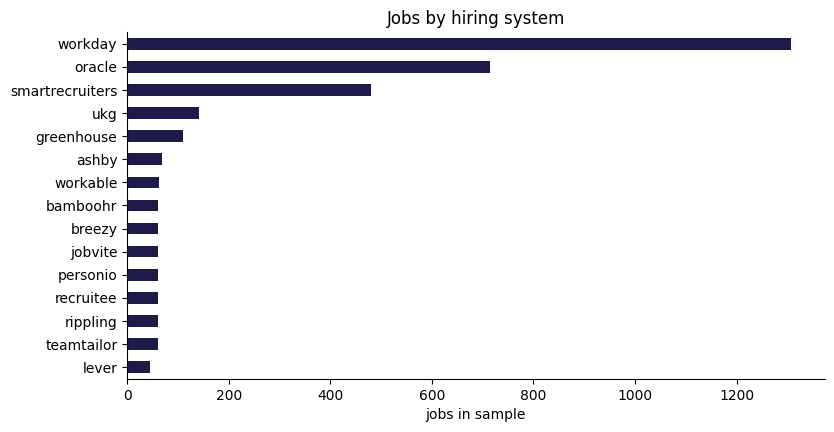

,jobs,employers,pay_stated
hiringSystem,,,
workday,1308,688,36%
oracle,714,353,18%
smartrecruiters,480,255,15%
ukg,142,116,31%
greenhouse,110,91,52%
ashby,68,56,53%
workable,63,53,29%
bamboohr,60,57,38%
breezy,60,46,40%


In [3]:
by_system = (jobs.groupby("hiringSystem")
             .agg(jobs=("title", "size"), employers=("company", "nunique"), pay_stated=("salaryMax", lambda s: s.notna().mean()))
             .sort_values("jobs", ascending=False))
ax = by_system["jobs"].plot.barh(color="#1e1b4b")
ax.invert_yaxis(); ax.set_xlabel("jobs in sample"); ax.set_ylabel(""); ax.set_title("Jobs by hiring system")
plt.show()
by_system.style.format({"pay_stated": "{:.0%}"})

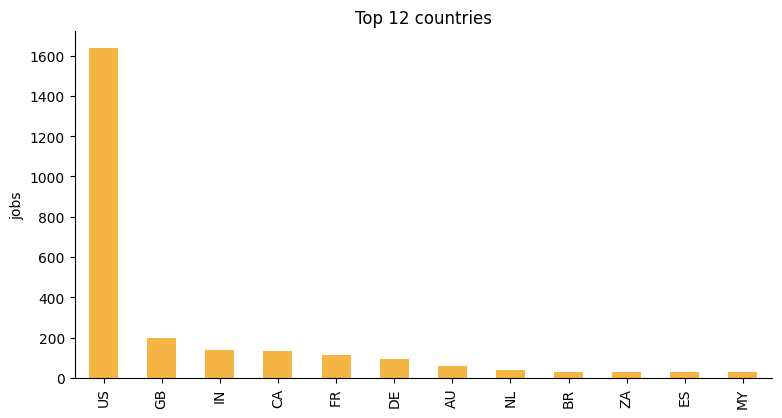

In [4]:
top_countries = jobs["country"].value_counts().head(12)
ax = top_countries.plot.bar(color="#f4b544")
ax.set_title("Top 12 countries"); ax.set_ylabel("jobs"); ax.set_xlabel("")
plt.show()

## 2. How often is pay stated?

US pay-transparency laws (California, Colorado, New York, Washington, Illinois and more) push many US postings
to include a range. Elsewhere it is far less common. Pay is read precision-first, so a
missing value usually means the posting simply did not state pay.

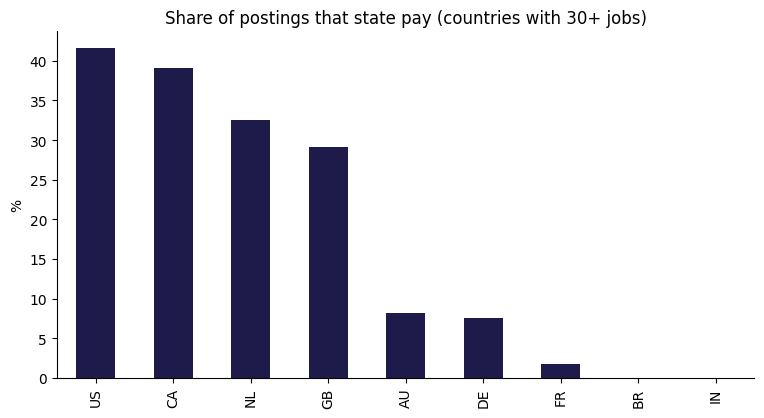

,jobs,pay_stated
country,,
US,1638,42%
CA,133,39%
NL,40,32%
GB,199,29%
AU,61,8%
DE,92,8%
FR,114,2%
BR,31,0%
IN,138,0%


In [5]:
pay_by_country = (jobs.assign(pay=has_pay)
                  .groupby("country").agg(jobs=("pay", "size"), pay_stated=("pay", "mean"))
                  .query("jobs >= 30").sort_values("pay_stated", ascending=False))
ax = pay_by_country["pay_stated"].mul(100).plot.bar(color="#1e1b4b")
ax.set_title("Share of postings that state pay (countries with 30+ jobs)"); ax.set_ylabel("%"); ax.set_xlabel("")
plt.show()
pay_by_country.style.format({"pay_stated": "{:.0%}"})

## 3. What US jobs pay, by type of job

Using US-dollar postings only, with every range annualised (`salaryAnnualMin` / `salaryAnnualMax`, where an
hourly rate is multiplied by 2,080). Job types come from simple title keywords, so treat them as a rough cut;
a title can match more than one.

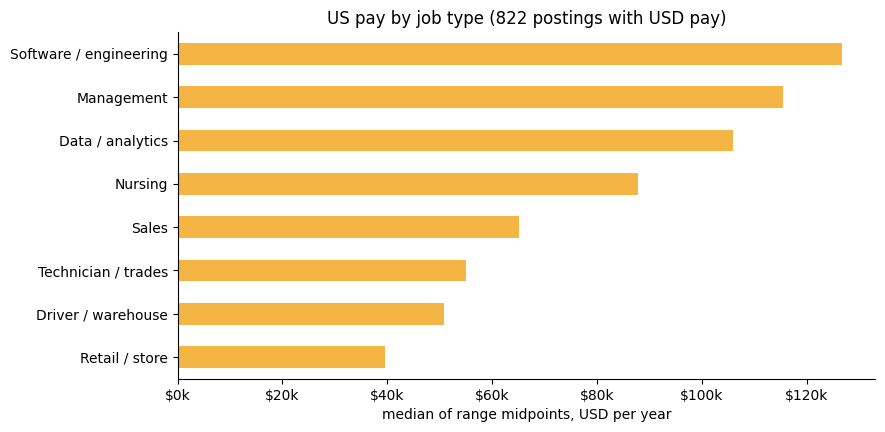

,postings,median annual pay (USD)
job type,,
Software / engineering,100,"$126,750"
Management,144,"$115,529"
Data / analytics,35,"$105,952"
Nursing,26,"$87,864"
Sales,72,"$65,050"
Technician / trades,70,"$55,104"
Driver / warehouse,27,"$50,838"
Retail / store,48,"$39,650"


In [6]:
usd = jobs[(jobs["salaryCurrency"] == "USD") & has_pay].copy()
usd["annual_mid"] = (usd["salaryAnnualMin"] + usd["salaryAnnualMax"]) / 2

families = {
    "Software / engineering": r"\bengineer|developer|software",
    "Data / analytics": r"\bdata\b|analyst|scientist",
    "Nursing": r"\bnurse|\brn\b|\blpn\b",
    "Sales": r"\bsales|account executive|business development",
    "Management": r"\bmanager|director|head of",
    "Technician / trades": r"technician|mechanic|electrician|installer",
    "Retail / store": r"\bretail|store|cashier|sales associate|merchandiser",
    "Driver / warehouse": r"\bdriver|warehouse|forklift|material handler",
}
rows = []
for name, pattern in families.items():
    m = usd["title"].str.contains(pattern, case=False, regex=True)
    if m.sum() >= 10:
        rows.append({"job type": name, "postings": int(m.sum()), "median annual pay (USD)": usd.loc[m, "annual_mid"].median()})
fam = pd.DataFrame(rows).sort_values("median annual pay (USD)", ascending=False).set_index("job type")
ax = fam["median annual pay (USD)"].plot.barh(color="#f4b544")
ax.invert_yaxis(); ax.set_xlabel("median of range midpoints, USD per year"); ax.set_ylabel("")
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"${v/1000:.0f}k"))
ax.set_title(f"US pay by job type ({len(usd):,} postings with USD pay)")
plt.show()
fam.style.format({"median annual pay (USD)": "${:,.0f}"})

## 4. Hourly vs salaried roles

`salaryPeriod` keeps the posting's own unit. Hourly roles cluster in retail, healthcare support, logistics and
trades; salaried roles carry most of the six-figure ranges.

salaryPeriod
year     411
hour     402
month      6
day        2
week       1


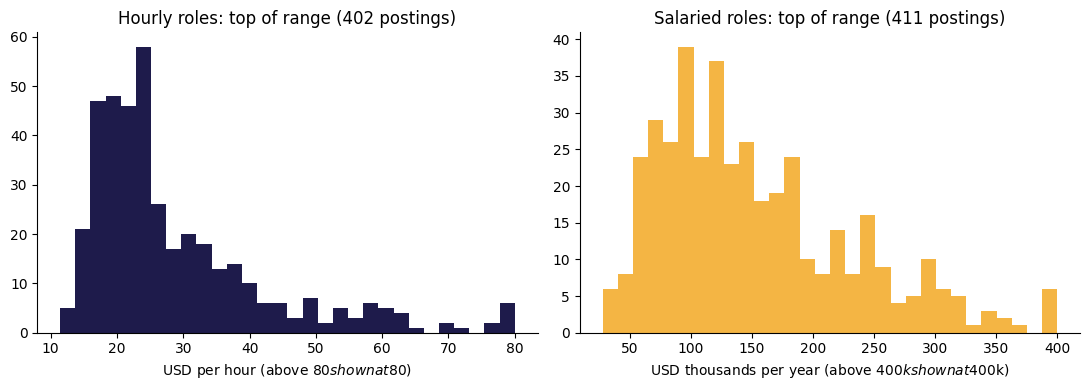

In [7]:
print(usd["salaryPeriod"].value_counts().to_string())
hourly = usd[usd["salaryPeriod"] == "hour"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(hourly["salaryMax"].clip(upper=80), bins=30, color="#1e1b4b")
axes[0].set_title(f"Hourly roles: top of range ({len(hourly)} postings)"); axes[0].set_xlabel("USD per hour (above $80 shown at $80)")
yearly = usd[usd["salaryPeriod"] == "year"]
axes[1].hist(yearly["salaryMax"].clip(upper=400_000) / 1000, bins=30, color="#f4b544")
axes[1].set_title(f"Salaried roles: top of range ({len(yearly)} postings)"); axes[1].set_xlabel("USD thousands per year (above $400k shown at $400k)")
plt.tight_layout(); plt.show()

In [8]:
# The best-paid postings in the sample
cols = ["title", "company", "location", "salaryMin", "salaryMax", "salaryPeriod", "hiringSystem"]
usd.sort_values("salaryAnnualMax", ascending=False)[cols].head(10).style.format({"salaryMin": "${:,.0f}", "salaryMax": "${:,.0f}"})

,title,company,location,salaryMin,salaryMax,salaryPeriod,hiringSystem
1122,Territory Account Manager,EquipmentShare,"Sioux Falls, SD","$150,000","$600,000",year,greenhouse
967,"Expert Imaging Lead, CVRM",Roche,South San Francisco,"$277,800","$515,800",year,workday
3205,"SVP, Customer Success & Professional Services",cloudinary,"San Jose, CA","$360,000","$440,000",year,lever
1081,DESIGN MANAGER – DESIGN BUILD HIGHWAY/ MANAGED LANES,HNTB,"Los Angeles, CA (Figueroa Street)","$274,665","$438,751",year,workday
2142,"Software Engineer, Infrastructure",thinkingmachines,San Francisco,"$300,000","$400,000",year,ashby
3350,Senior Enterprise Account Executive (Bay Area),sysdig,San Francisco,"$318,000","$398,000",year,lever
1362,"Senior Principal Scientist, Pathologist",Roche,South San Francisco,"$198,900","$369,300",year,workday
1498,"Sr. Director, DC Commissioning",Oracle,United States,"$169,800","$355,400",year,oracle
1729,"Director of User Experience, Purple Autonomous SOC",SentinelOne,United States - Remote,"$237,188","$355,350",year,greenhouse
1914,"Director, Product Marketing, GTM",temporal,"Seattle, Washington","$270,000","$350,000",year,ashby


## Going further

This is a one-week sample. The full index behind it holds about 1.7 million open jobs from 19,000+
companies across the same 15 hiring systems, refreshed every night, with descriptions and the same pay
fields. It can be searched by title, location, company, pay and date, or set to return only new jobs each day,
through the [Career Site Jobs API](https://apify.com/viridian_layout_ea2/career-site-jobs-api) on Apify
($2 per 1,000 jobs).

Questions or a custom extract: chazmichael_michaels@icloud.com (CMM Research).